In [85]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm import tqdm
# from extract_features import GenerateFeatures
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import scale, StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE





Normalize the train data and applied the normalization params to the test set

In [86]:
train_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/3_class/train_set/two_class_1s_0.8.csv'
test_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/3_class/test_set/two_class_1s_0.8.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


train_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
test_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']


View label distribution

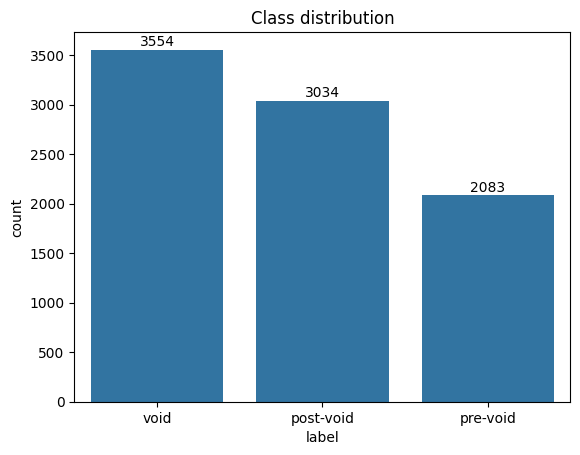

In [87]:
plt.figure()
ax = sns.countplot(x='label',
                   data=train_data,
                   order=train_data.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()


In [88]:
# Apply SMOTE to training data
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



In [92]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
# y_train_encoded = label_encoder.fit_transform(y_train_smote) 
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [93]:
model = XGBClassifier(random_state = 42)
# model = RandomForestClassifier(random_state=42)

In [94]:
from sklearn import set_config
set_config(display="text")  # avoids estimator_html_repr

In [95]:
# eval_set = [(X_train_smote, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train_smote, y_train_encoded, eval_set=eval_set, verbose=False)

# eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)
# model.fit(X_train, y_train_encoded)

eval_set = [(X_train_selected, y_train_encoded), (X_test_selected, y_test_encoded)]
model.fit(X_train_selected, y_train_encoded, eval_set=eval_set, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [96]:
# classes = ['void', 'non-void']
classes = ['pre-void','void', 'post-void']

In [97]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test_selected))
y_pred_prob = model.predict_proba(X_test_selected)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred, labels=classes)

print(report)

              precision    recall  f1-score   support

    pre-void       0.31      0.57      0.40       584
        void       0.70      0.60      0.65      1227
   post-void       0.59      0.46      0.52      1365

    accuracy                           0.53      3176
   macro avg       0.53      0.54      0.52      3176
weighted avg       0.58      0.53      0.54      3176



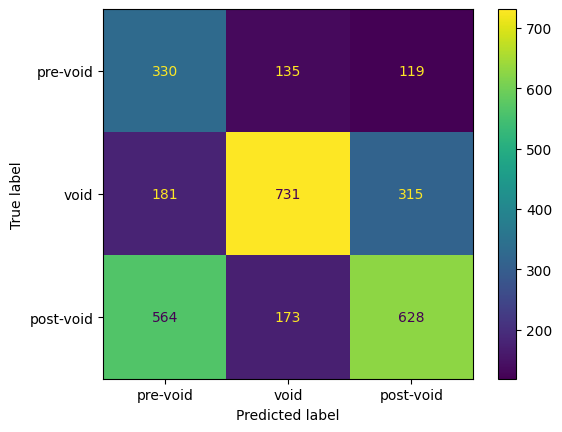

In [98]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()


In [53]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_dict

{'post-void': {'precision': 0.7370892018779343,
  'recall': 0.6085271317829457,
  'f1-score': 0.6666666666666666,
  'support': 258.0},
 'pre-void': {'precision': 0.42038216560509556,
  'recall': 0.6407766990291263,
  'f1-score': 0.5076923076923077,
  'support': 103.0},
 'void': {'precision': 0.7276595744680852,
  'recall': 0.7008196721311475,
  'f1-score': 0.7139874739039666,
  'support': 244.0},
 'accuracy': 0.6512396694214876,
 'macro avg': {'precision': 0.6283769806503717,
  'recall': 0.6500411676477398,
  'f1-score': 0.6294488160876469,
  'support': 605.0},
 'weighted avg': {'precision': 0.6793674600199084,
  'recall': 0.6512396694214876,
  'f1-score': 0.6586863658262405,
  'support': 605.0}}

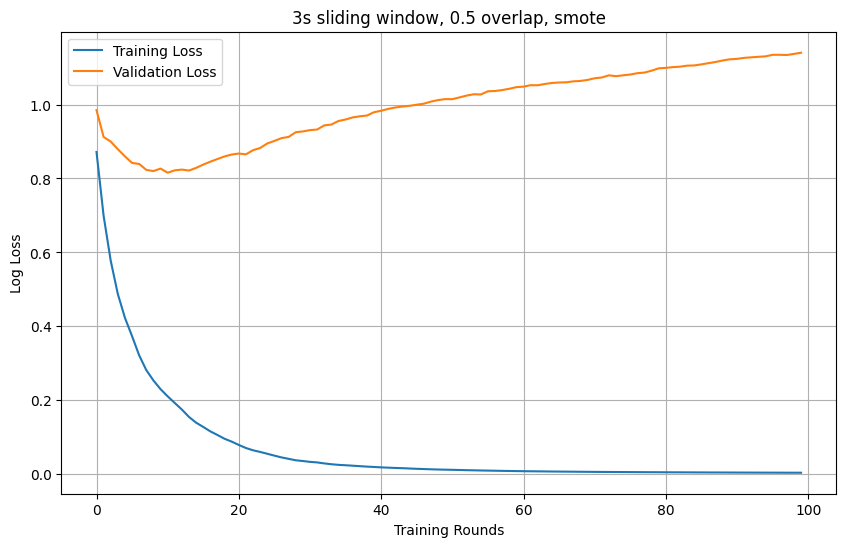

In [54]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
test_loss = results['validation_1']['mlogloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('3s sliding window, 0.5 overlap, smote')
plt.legend()
plt.grid(True)
# plt.savefig('model_plots/two_class_results/loss_3s_0.5_smote.png')
plt.show()

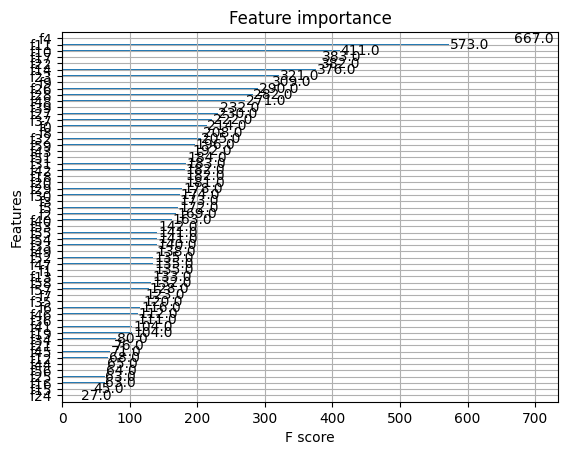

In [100]:
plot_importance(model)
plt.show()

1. For every file in the train and test.
2. Call the tune_hyperparameters function.
3. tune_hyperparameters has the train set of a particular dataset as an argument. 
4. tune_hyperparameters returns the hyperparameters tuned for each model that maximizes accuracy.